## Rohlik Sales Prediction

---
format: 
    html:
        page-layout: full
        embed_resources: false
        grid: 
            body-width: 800px
            fontsize: 18pt
echo: true
warning: false
toc: True
---

![grocery shelves](https://images.pexels.com/photos/2449665/pexels-photo-2449665.jpeg)
<sup>Author: Carlo Martin Alcordo, pexels.com</sup>

## About

Predicting sales values is essential for planning, supplying chains, delivery logistics and inventory management. With accurate forecast, businesses can minimaze waste of resources and volume of unnecessary work-related tasks.

The data comes from kaggle competition [Rohlik Sales Forecasting Challenge](https://www.kaggle.com/competitions/rohlik-sales-forecasting-challenge-v2/overview).

The project analyzes historical sales data across multiple European warehouses of grocery chain [Rohlik](https://www.rohlik.group). The goal is to understand sales patterns over time and to engineer meaningful features that can later be used for demand forecasting.

Data:\
sales_train.csv - training set containing the historical sales data for given date and inventory with selected features described below\
sales_test.csv - testing set\
inventory.csv - additional information about inventory like its product (same products across all warehouses share same product unique id and name, but have different unique id)\
solution.csv - full submission file in the correct format\
calendar.csv - calendar containing data about holidays or warehouse specific events, some columns are already in the train data but there are additional rows in this file for dates where some warehouses could be closed due to public holiday or Sunday (and therefore they are not in the train set)

::: {.content-hidden}

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor
import lightgbm as lgb


## Loading Datasets

In [2]:
FILENAME= "calendar.csv"
DATADIR = "../rohlik_project/csv/"

calendar_df = pd.read_csv(DATADIR + FILENAME, header=0)

In [3]:
FILENAME= "inventory.csv"
DATADIR = "../rohlik_project/csv/"

inventory_df = pd.read_csv(DATADIR + FILENAME, header=0)

In [4]:
FILENAME= "sales_test.csv"
DATADIR = "../rohlik_project/csv/"

sales_test_df = pd.read_csv(DATADIR + FILENAME, header=0)

In [5]:
FILENAME= "sales_train.csv"
DATADIR = "../rohlik_project/csv/"

sales_train_df = pd.read_csv(DATADIR + FILENAME, low_memory=False)

In [6]:
FILENAME= "solution.csv"
DATADIR = "../rohlik_project/csv/"

solution_df = pd.read_csv(DATADIR + FILENAME)

In [7]:
FILENAME= "test_weights.csv"
DATADIR = "../rohlik_project/csv/"

test_weights_df = pd.read_csv(DATADIR + FILENAME)

:::

## Information about datasets

##### calendar_df

In [8]:
#| echo: false
calendar_df.head()

,date,holiday_name,holiday,shops_closed,winter_school_holidays,school_holidays,warehouse
0,2022-03-16,NaN,0,0,0,0,Frankfurt_1
1,2020-03-22,NaN,0,0,0,0,Frankfurt_1
2,2018-02-07,NaN,0,0,0,0,Frankfurt_1
3,2018-08-10,NaN,0,0,0,0,Frankfurt_1
4,2017-10-26,NaN,0,0,0,0,Prague_2


In [9]:
#| echo: false
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23016 entries, 0 to 23015
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    23016 non-null  object
 1   holiday_name            930 non-null    object
 2   holiday                 23016 non-null  int64 
 3   shops_closed            23016 non-null  int64 
 4   winter_school_holidays  23016 non-null  int64 
 5   school_holidays         23016 non-null  int64 
 6   warehouse               23016 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.2+ MB


In [10]:
#| echo: false
display(calendar_df.date.min())
display(calendar_df.date.max())

'2016-01-01'

'2024-12-31'

The earliest and the latest date in the dataset.

##### inventory_df

In [11]:
#| echo: false
inventory_df.head()

,unique_id,product_unique_id,name,L1_category_name_en,L2_category_name_en,L3_category_name_en,L4_category_name_en,warehouse
0,5255,2583,Pastry_196,Bakery,Bakery_L2_14,Bakery_L3_26,Bakery_L4_1,Prague_3
1,4948,2426,Herb_19,Fruit and vegetable,Fruit and vegetable_L2_30,Fruit and vegetable_L3_86,Fruit and vegetable_L4_1,Prague_3
2,2146,1079,Beet_2,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_65,Fruit and vegetable_L4_34,Prague_1
3,501,260,Chicken_13,Meat and fish,Meat and fish_L2_13,Meat and fish_L3_27,Meat and fish_L4_5,Prague_1
4,4461,2197,Chicory_1,Fruit and vegetable,Fruit and vegetable_L2_17,Fruit and vegetable_L3_33,Fruit and vegetable_L4_1,Frankfurt_1


In [12]:
#| echo: false
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5432 entries, 0 to 5431
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   unique_id            5432 non-null   int64 
 1   product_unique_id    5432 non-null   int64 
 2   name                 5432 non-null   object
 3   L1_category_name_en  5432 non-null   object
 4   L2_category_name_en  5432 non-null   object
 5   L3_category_name_en  5432 non-null   object
 6   L4_category_name_en  5432 non-null   object
 7   warehouse            5432 non-null   object
dtypes: int64(2), object(6)
memory usage: 339.6+ KB


#### sales_train_df

In [13]:
#| echo: false
sales_train_df.head()

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,4845,2024-03-10,Budapest_1,6436.0,16.34,646.26,1.00,0.00000,0.0,0.0,0.0,0.15312,0.0,0.0
1,4845,2021-05-25,Budapest_1,4663.0,12.63,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
2,4845,2021-12-20,Budapest_1,6507.0,34.55,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
3,4845,2023-04-29,Budapest_1,5463.0,34.52,646.26,0.96,0.20024,0.0,0.0,0.0,0.15312,0.0,0.0
4,4845,2022-04-01,Budapest_1,5997.0,35.92,486.41,1.00,0.00000,0.0,0.0,0.0,0.15649,0.0,0.0


In [14]:
#| echo: false
sales_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   unique_id        1048575 non-null  int64  
 1   date             1048575 non-null  object 
 2   warehouse        1048575 non-null  object 
 3   total_orders     1048556 non-null  float64
 4   sales            1048556 non-null  float64
 5   sell_price_main  1048575 non-null  float64
 6   availability     1048575 non-null  float64
 7   type_0_discount  1048575 non-null  float64
 8   type_1_discount  1048575 non-null  float64
 9   type_2_discount  1048575 non-null  float64
 10  type_3_discount  1048575 non-null  float64
 11  type_4_discount  1048575 non-null  float64
 12  type_5_discount  1048575 non-null  float64
 13  type_6_discount  1048575 non-null  float64
dtypes: float64(11), int64(1), object(2)
memory usage: 112.0+ MB


In [15]:
#| echo: false
display(sales_train_df.date.min())
display(sales_train_df.date.max())

'2020-08-01'

'2024-06-02'

The earliest and the latest date in the dataset.

#### sales_test_df

In [16]:
#| echo: false
sales_test_df.head()

,unique_id,date,warehouse,total_orders,sell_price_main,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,1226,2024-06-03,Brno_1,8679.0,13.13,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
1,1226,2024-06-11,Brno_1,8795.0,13.13,0.15873,0.0,0.0,0.0,0.0,0.0,0.0
2,1226,2024-06-13,Brno_1,10009.0,13.13,0.15873,0.0,0.0,0.0,0.0,0.0,0.0
3,1226,2024-06-15,Brno_1,8482.0,13.13,0.15873,0.0,0.0,0.0,0.0,0.0,0.0
4,1226,2024-06-09,Brno_1,8195.0,13.13,0.00000,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#| echo: false
sales_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unique_id        47021 non-null  int64  
 1   date             47021 non-null  object 
 2   warehouse        47021 non-null  object 
 3   total_orders     47021 non-null  float64
 4   sell_price_main  47021 non-null  float64
 5   type_0_discount  47021 non-null  float64
 6   type_1_discount  47021 non-null  float64
 7   type_2_discount  47021 non-null  float64
 8   type_3_discount  47021 non-null  float64
 9   type_4_discount  47021 non-null  float64
 10  type_5_discount  47021 non-null  float64
 11  type_6_discount  47021 non-null  float64
dtypes: float64(9), int64(1), object(2)
memory usage: 4.3+ MB


In [18]:
#| echo: false
display(sales_test_df.date.min())
display(sales_test_df.date.max())

'2024-06-03'

'2024-06-16'

 The earliest and the latest date in the dataset.

##### solution_df

In [19]:
#| echo: false
solution_df.head(5)

,id,sales_hat
0,Brno_1_1226_2024-06-03,242.320371
1,Brno_1_1226_2024-06-11,232.836769
2,Brno_1_1226_2024-06-13,255.140114
3,Brno_1_1226_2024-06-15,233.518247
4,Brno_1_1226_2024-06-09,227.516824


In [20]:
#| echo: false
solution_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         47021 non-null  object 
 1   sales_hat  47021 non-null  float64
dtypes: float64(1), object(1)
memory usage: 734.8+ KB


##### test_weight_df

In [21]:
#| echo: false
test_weights_df.head(5)

,unique_id,weight
0,0,2.535369
1,1,3.888933
2,2,5.885237
3,3,2.139552
4,5,3.021715


In [22]:
#| echo: false
test_weights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5390 entries, 0 to 5389
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unique_id  5390 non-null   int64  
 1   weight     5390 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 84.3 KB


## Exploratory Data Analysis (EDA)

::: {.content-hidden}

In [35]:
sales_train_df["date"] = pd.to_datetime(sales_train_df["date"])
sales_test_df["date"] = pd.to_datetime(sales_test_df["date"])
calendar_df["date"] = pd.to_datetime(calendar_df["date"])

In [36]:
sales_train_df["is_test"] = 0
sales_test_df["is_test"] = 1

data = pd.concat([sales_train_df, sales_test_df], axis=0)
data = data.sort_values(["unique_id", "date"])


In [37]:
# Merging
data = data.merge(calendar_df, on=["date", "warehouse"], how="left")
data = data.merge(inventory_df, on=['unique_id', 'warehouse'], how='left')
data = data.merge(test_weights_df, on=['unique_id'], how='left')

In [39]:
# Data Cleaning and Feature Engineering

data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["day_of_week"] = data["date"].dt.dayofweek
data["weekend"] = (data["day_of_week"] >= 5).astype("int8")

# keep holiday numeric
data["holiday"] = data["holiday"].astype("int8")

# categorical ids
data["warehouse"] = data["warehouse"].astype("category")
data["day_of_week"] = data["day_of_week"].astype("category")

:::

#### Daily Sales

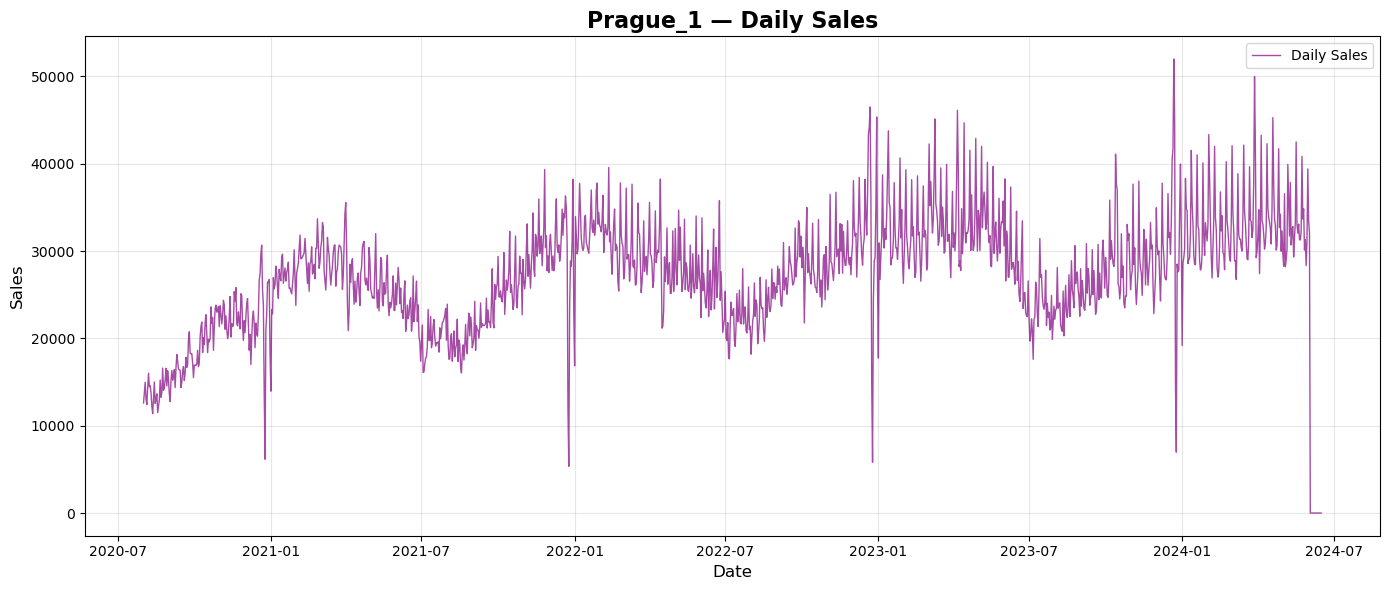

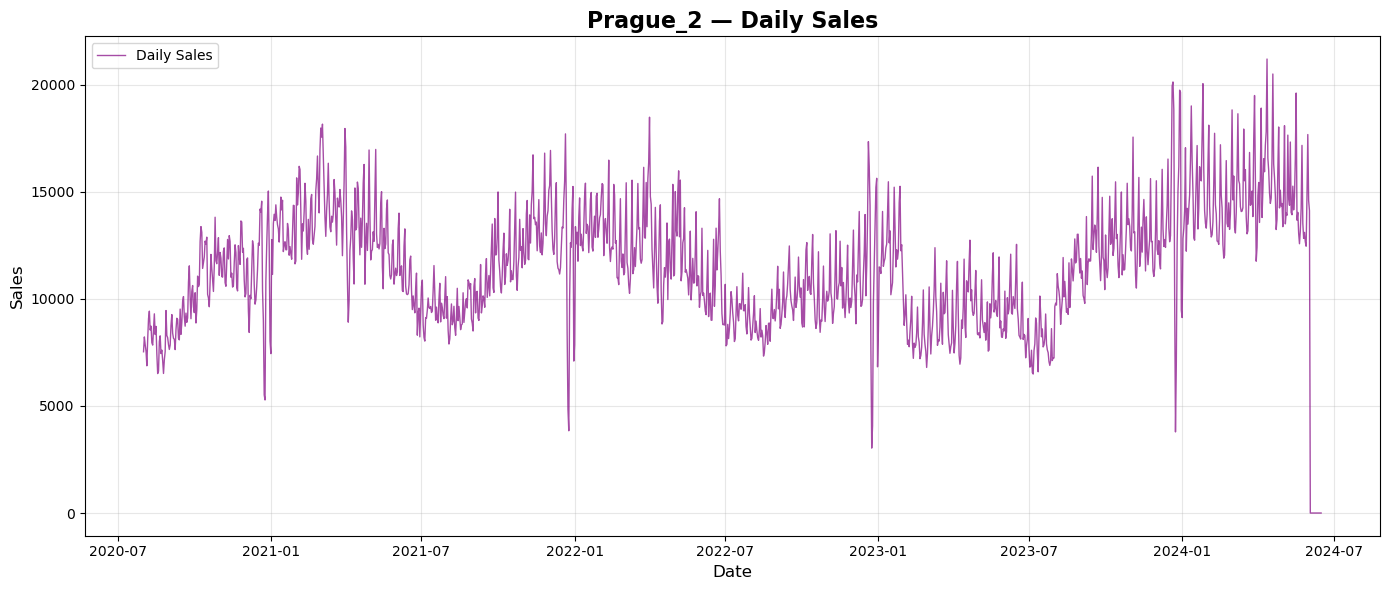

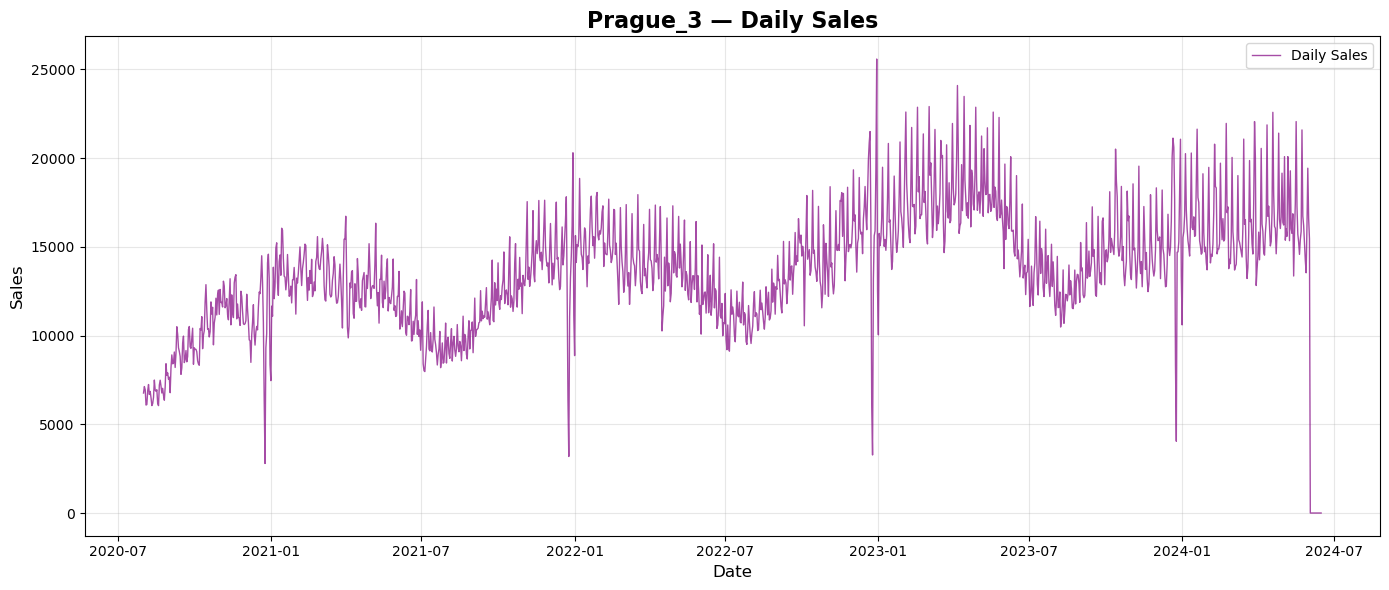

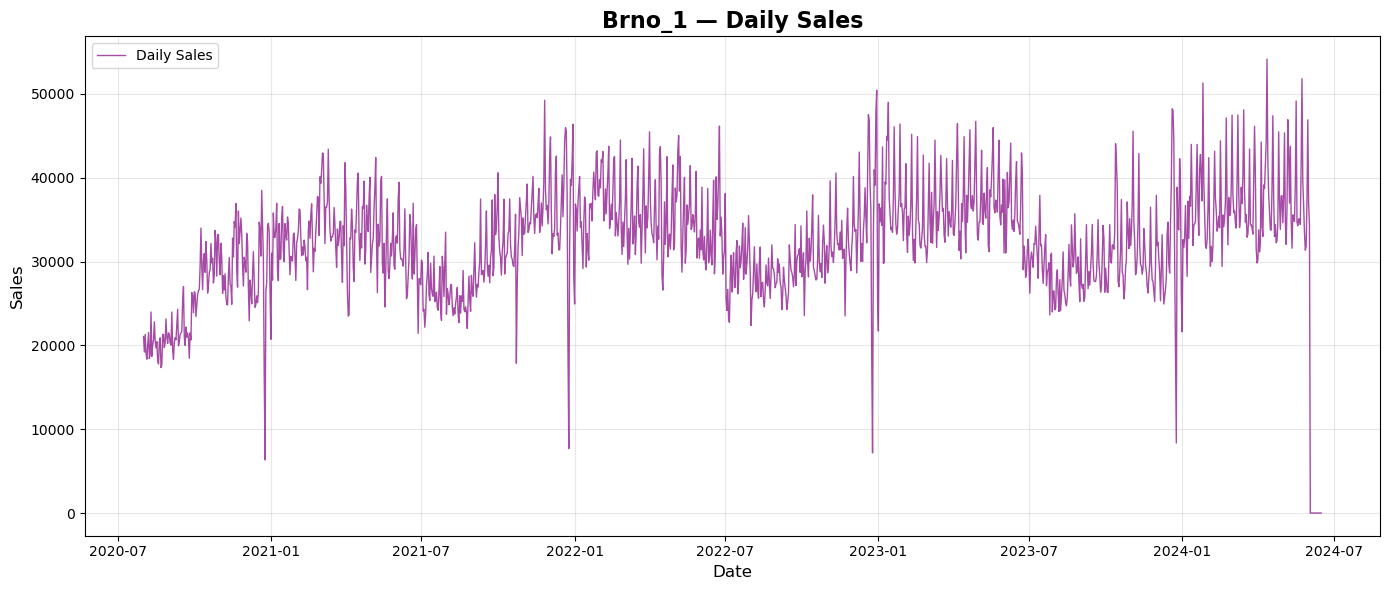

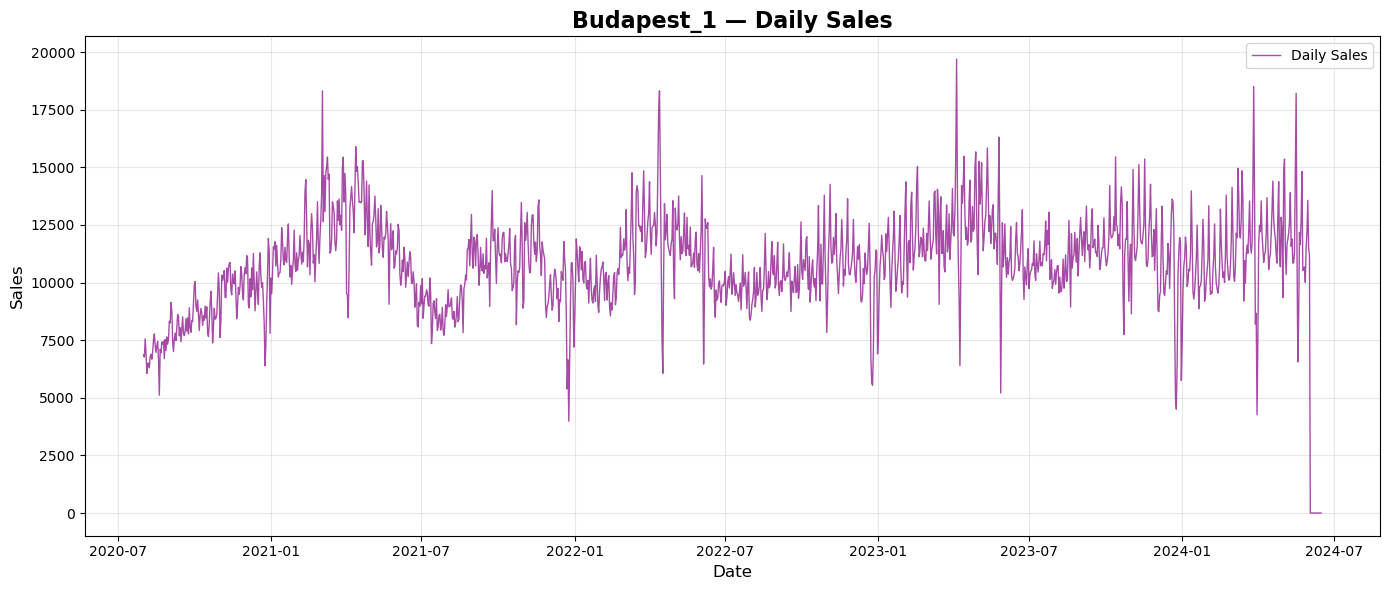

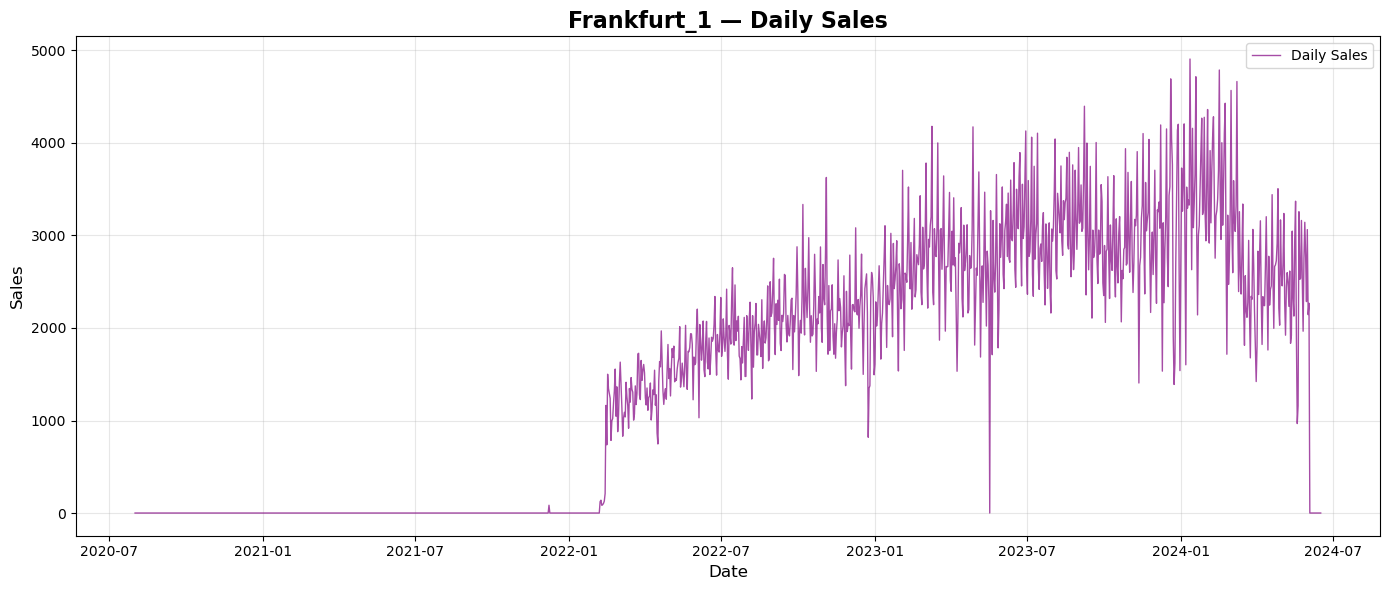

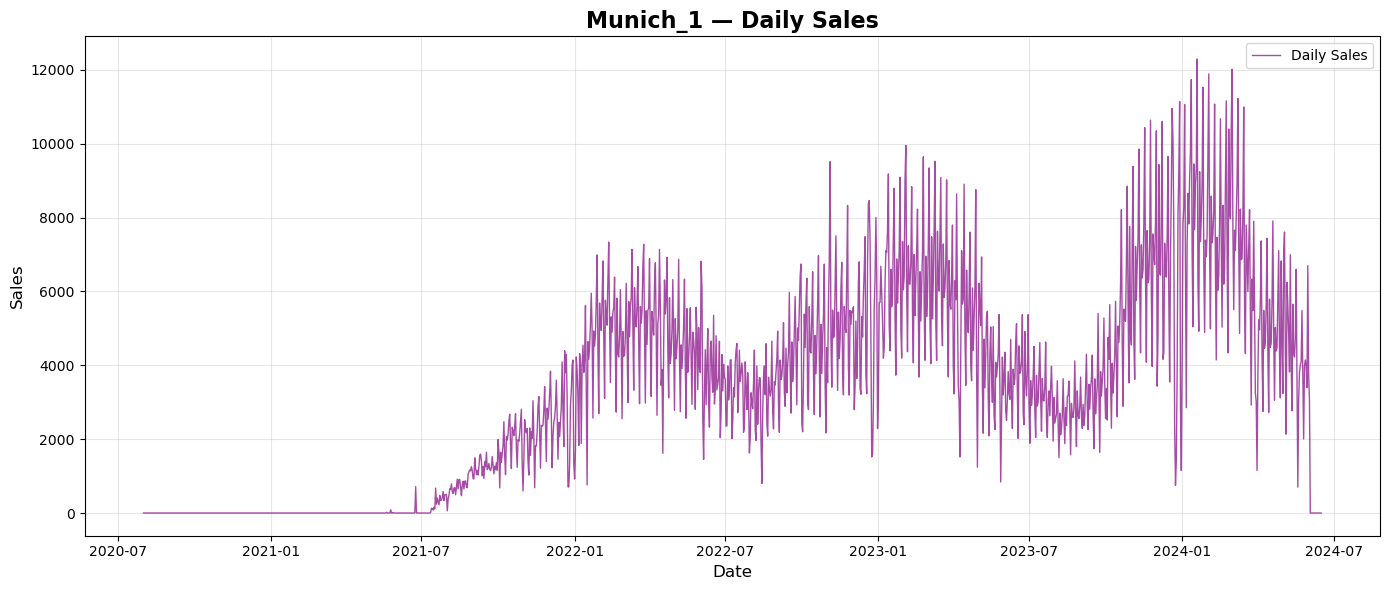

In [41]:
#| echo: false
# Group by date and warehouse, sum sales, reset index right away
ds = (data
      .groupby(["date", "warehouse"])["sales"]
      .sum()
      .reset_index()
      .sort_values(["warehouse", "date"]))

warehouses = ["Prague_1", "Prague_2", "Prague_3", "Brno_1",
              "Budapest_1", "Frankfurt_1", "Munich_1"]


ds["date"] = pd.to_datetime(ds["date"])

# Plot each warehouse
for wh in warehouses:
    df_wh = ds[ds["warehouse"] == wh]
    if df_wh.empty:
        print(f"⚠️ No data for {wh}")
        continue

    plt.figure(figsize=(14, 6))
    plt.plot(df_wh["date"], df_wh["sales"],
             label="Daily Sales", linewidth=1.0, color="purple", alpha=0.7)
    plt.title(f"{wh} — Daily Sales", fontsize=16, weight="bold")
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Sales", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()




Prague and Brno are both in Czech Republic. Summary sales show simmilar repeated pattern of sales during every year with tendency to grow every year.
Budapest is the capital of Hungary. Summary sales plot shows again repeated pattern of sales over years, but a bit different than plots from Czech Republic. There seems to be no tendency of growth over the years.
City of Munich is in Germany. Plot of summary daily sales shows again repeated pattern of sales over every year with tendency to grow each year.
City of Munich is in Germany. Plot of summary daily sales does not seems to show repeated pattern of sales over every year with tendency to grow each year.

#### Average sales during weekdays

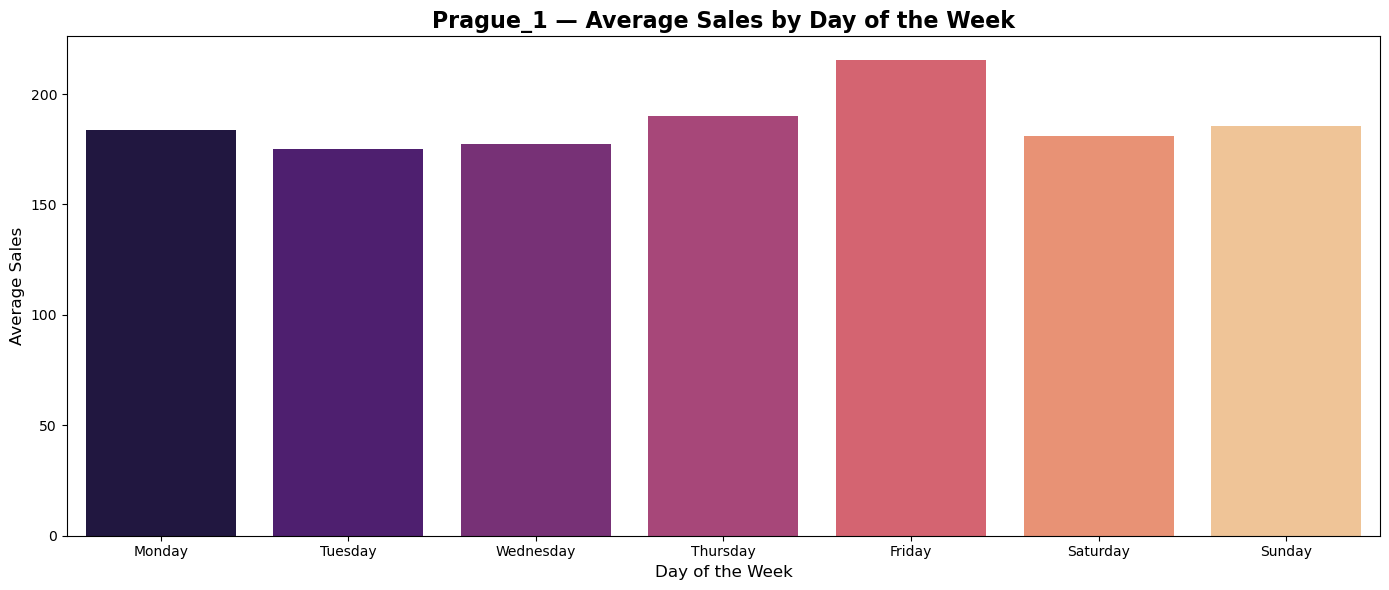

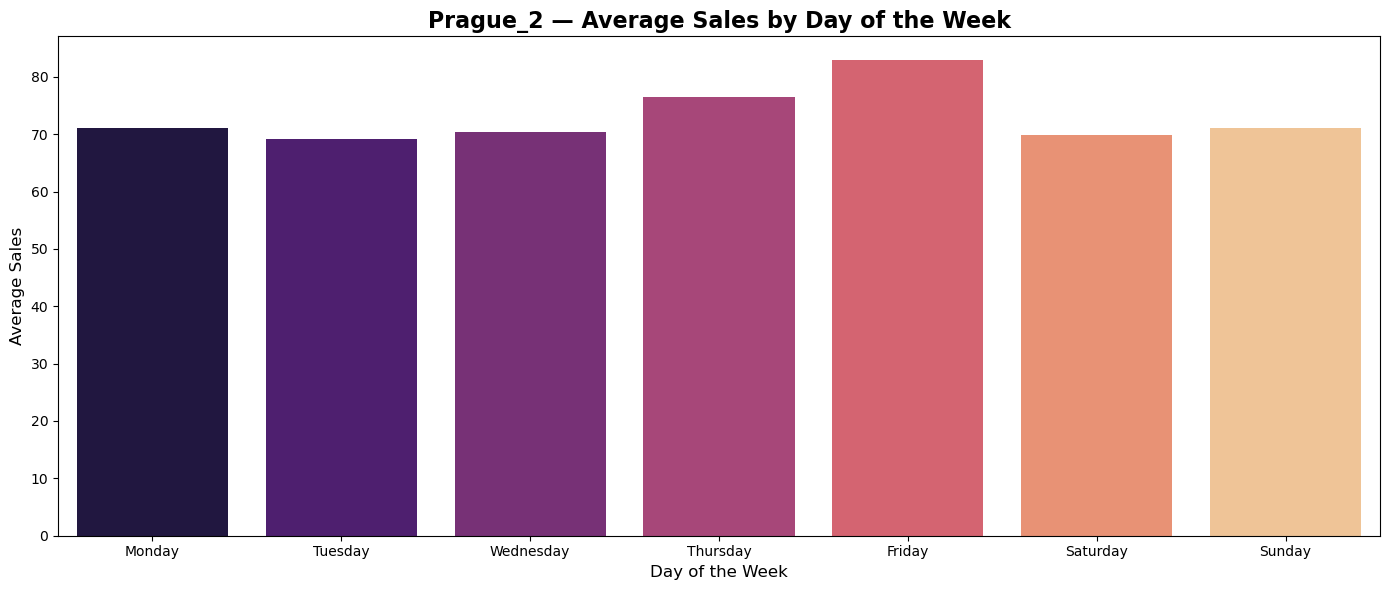

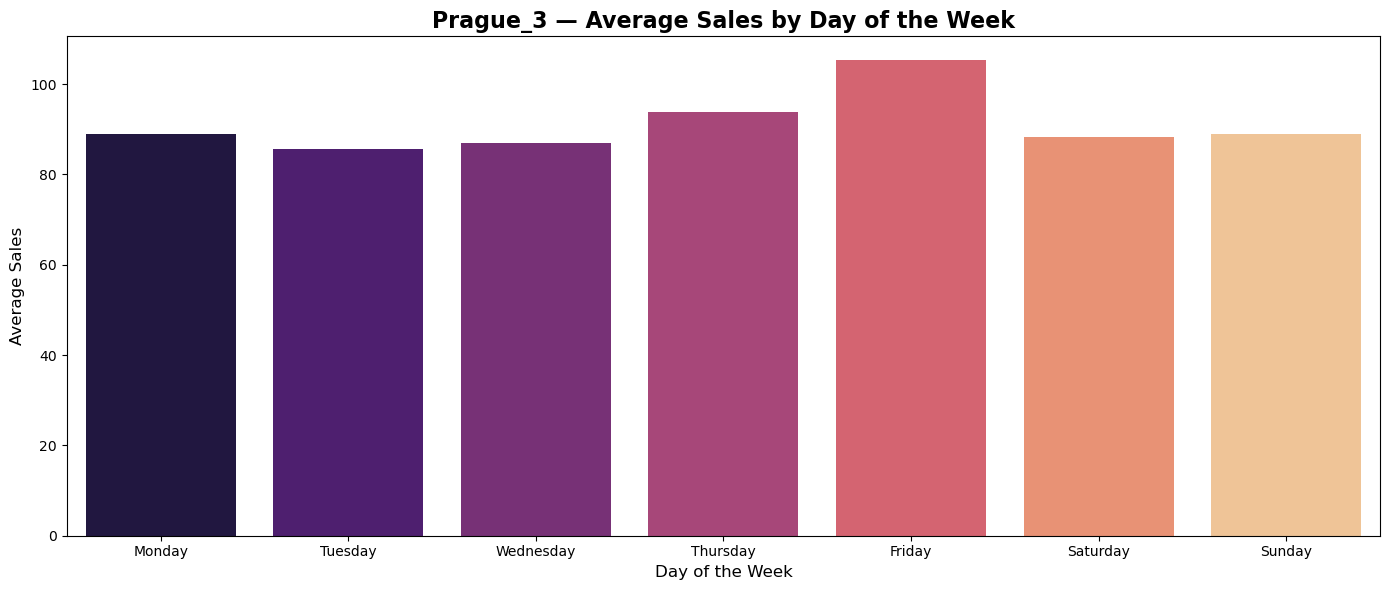

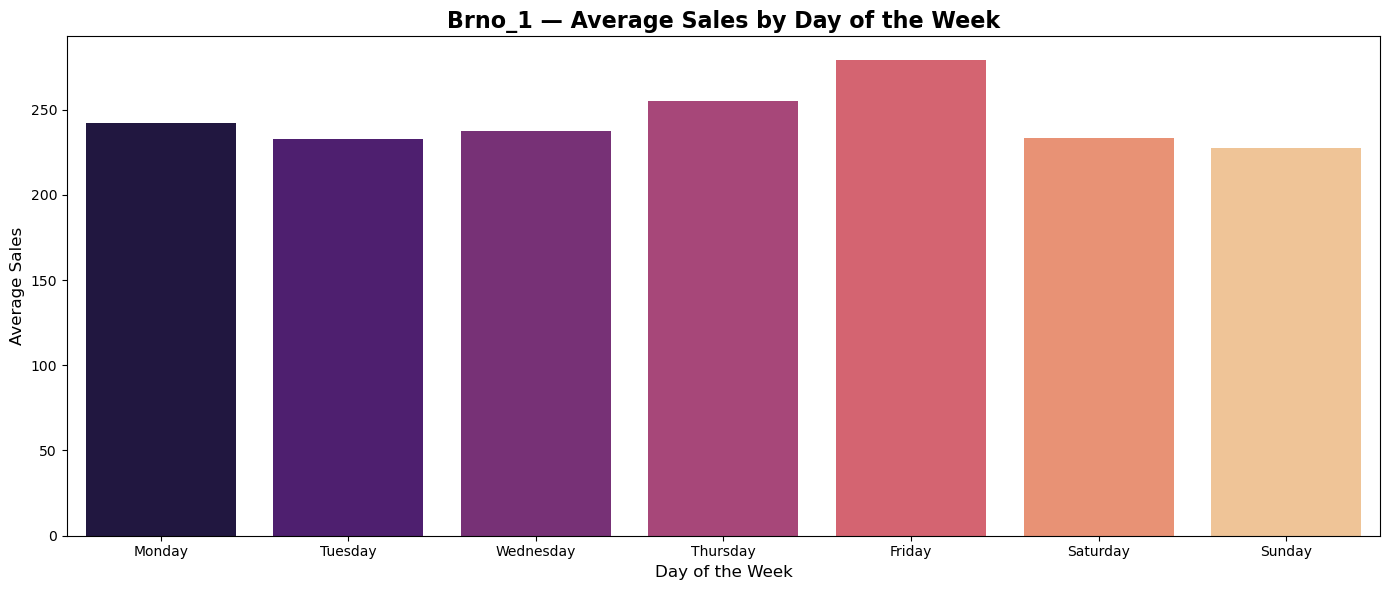

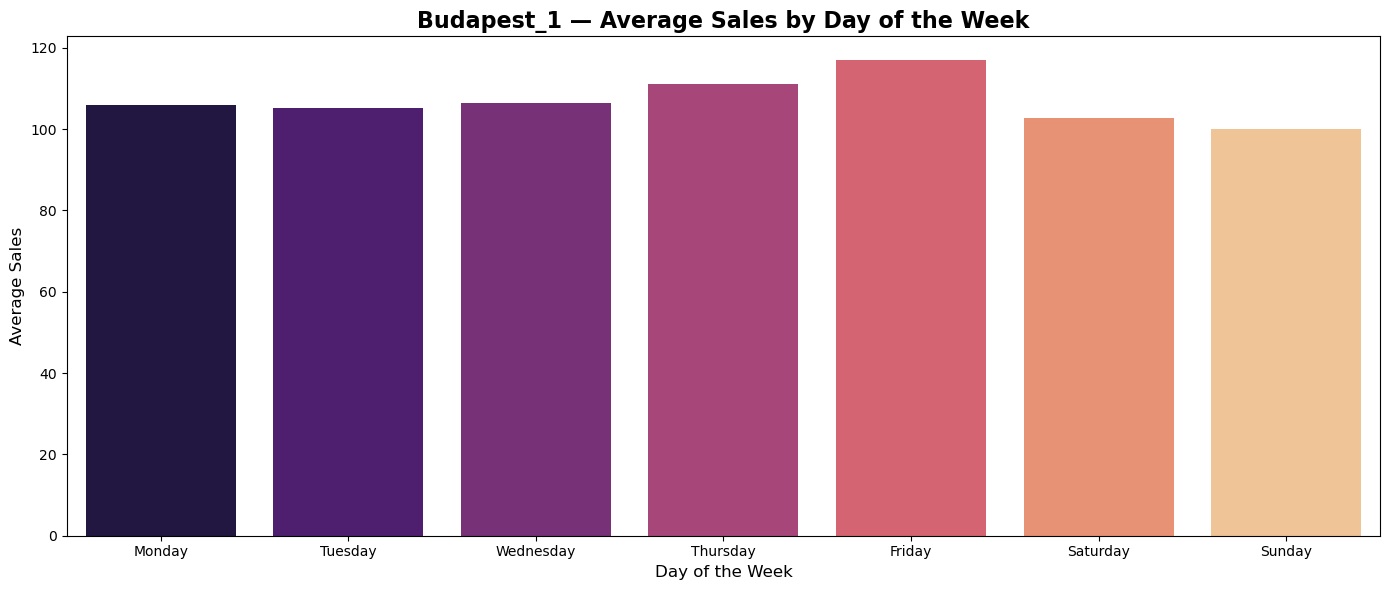

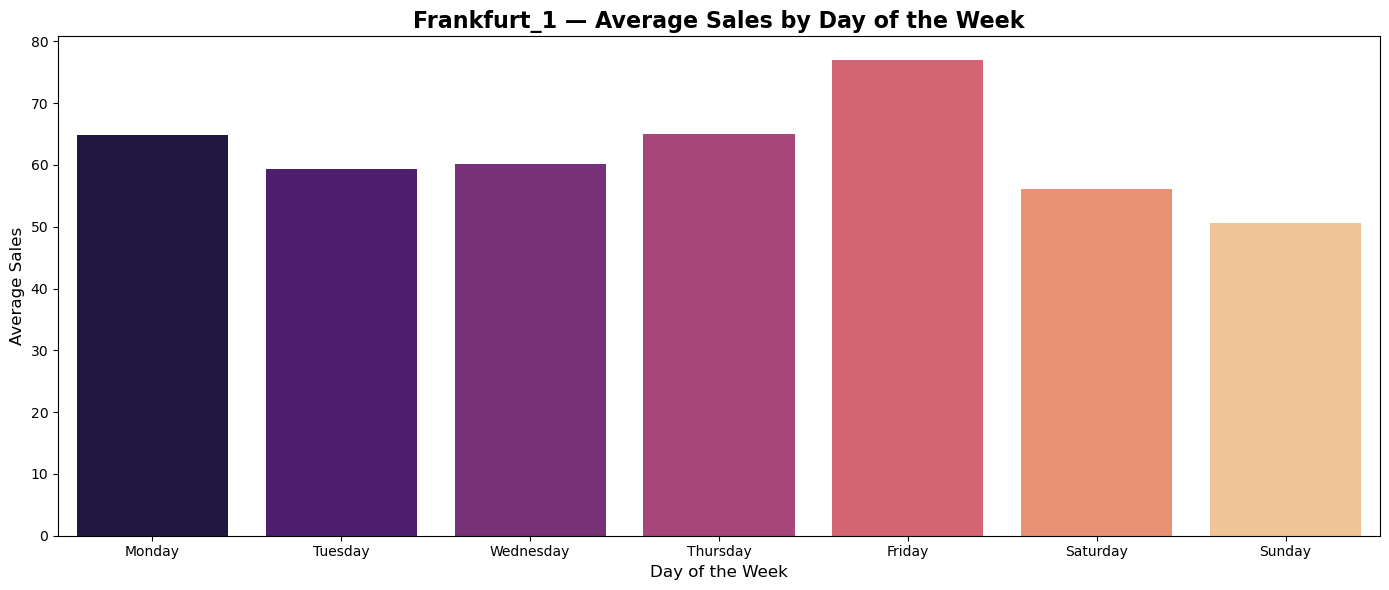

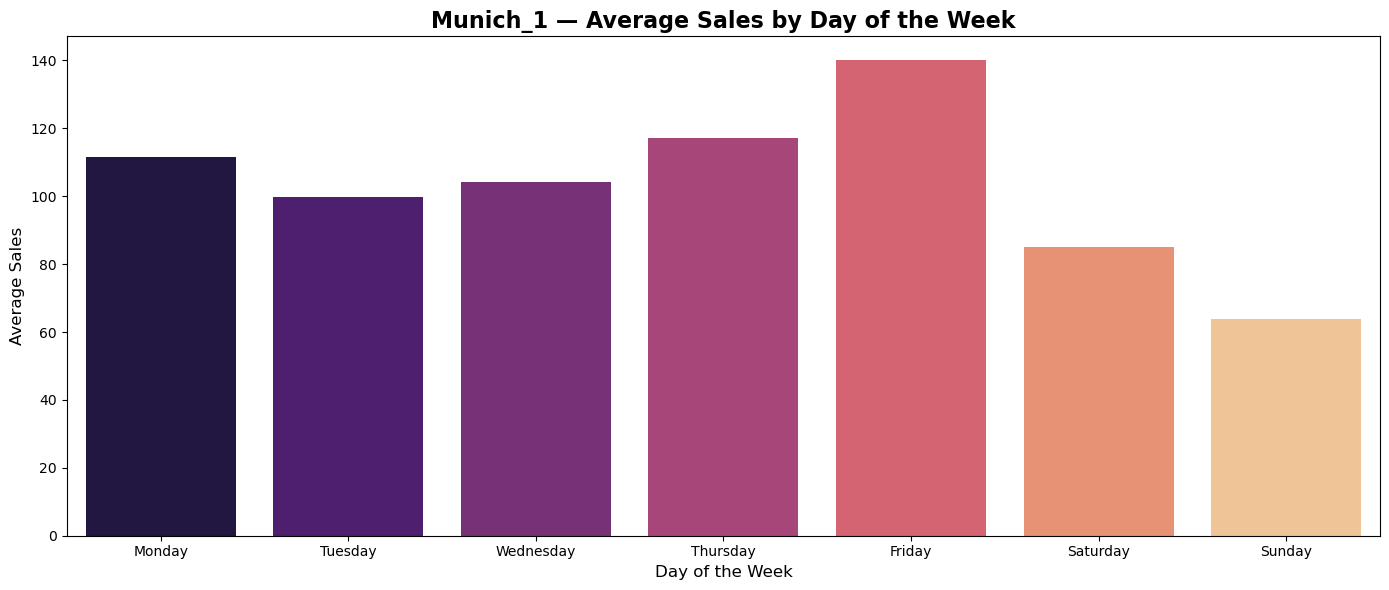

In [30]:
#| echo: false
# create day names just for plotting
data["day_name"] = data["date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
data["day_name"] = pd.Categorical(data["day_name"], categories=day_order, ordered=True)

# average sales by warehouse and weekday
week_average = (data
    .groupby(["warehouse", "day_name"], as_index=False)
    .agg(sales=("sales", "mean"))
)

for wh in warehouses:
    df_wh = week_average[week_average["warehouse"] == wh]
    if df_wh.empty:
        print(f"⚠️ No data for {wh}")
        continue

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(
        x="day_name", y="sales", data=df_wh,
        order=day_order, ax=ax, palette="magma"
    )

    ax.set_title(f"{wh} — Average Sales by Day of the Week", fontsize=16, weight="bold")
    ax.set_xlabel("Day of the Week", fontsize=12)
    ax.set_ylabel("Average Sales", fontsize=12)
    plt.tight_layout()
    plt.show()

Plots of average sales during weekdays shows tendency of custumers in all countries to do shopping on Thurdays and Fridays.

#### Average monthly sales

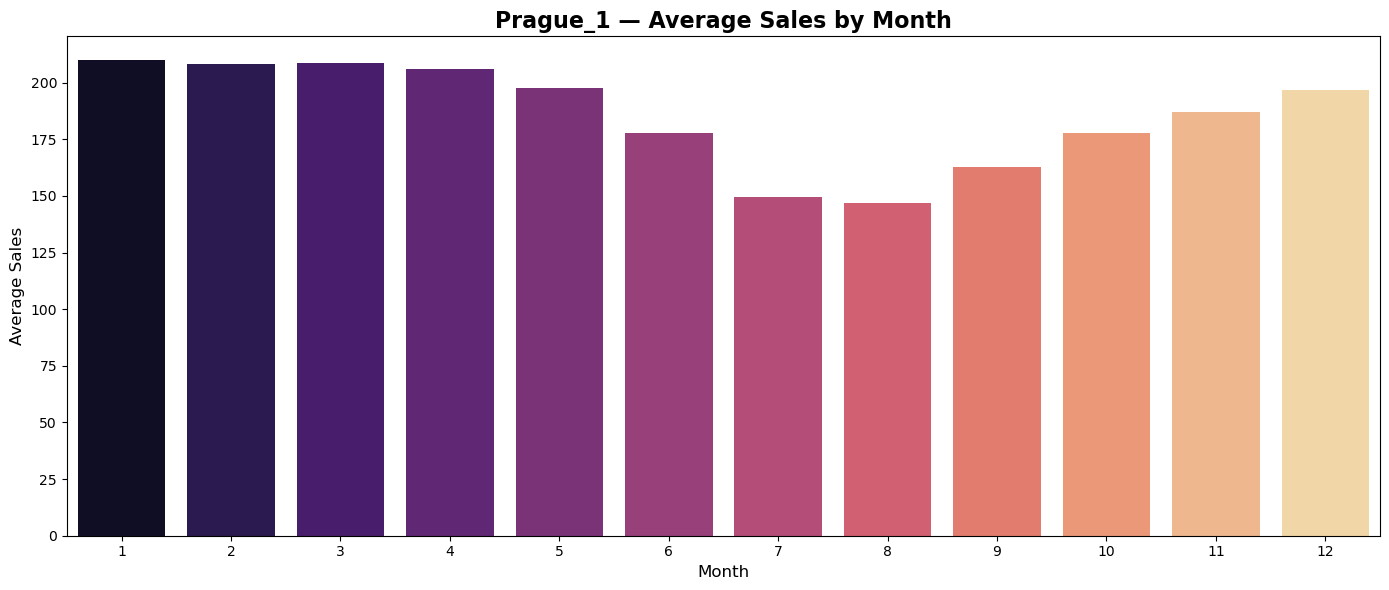

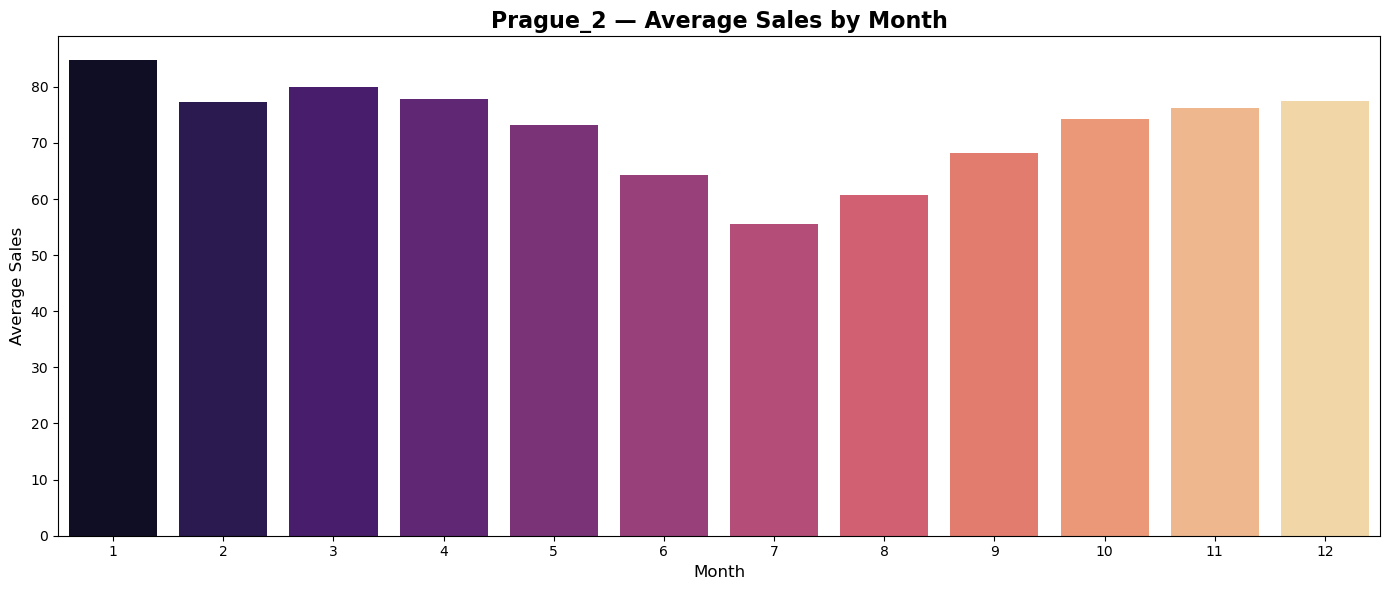

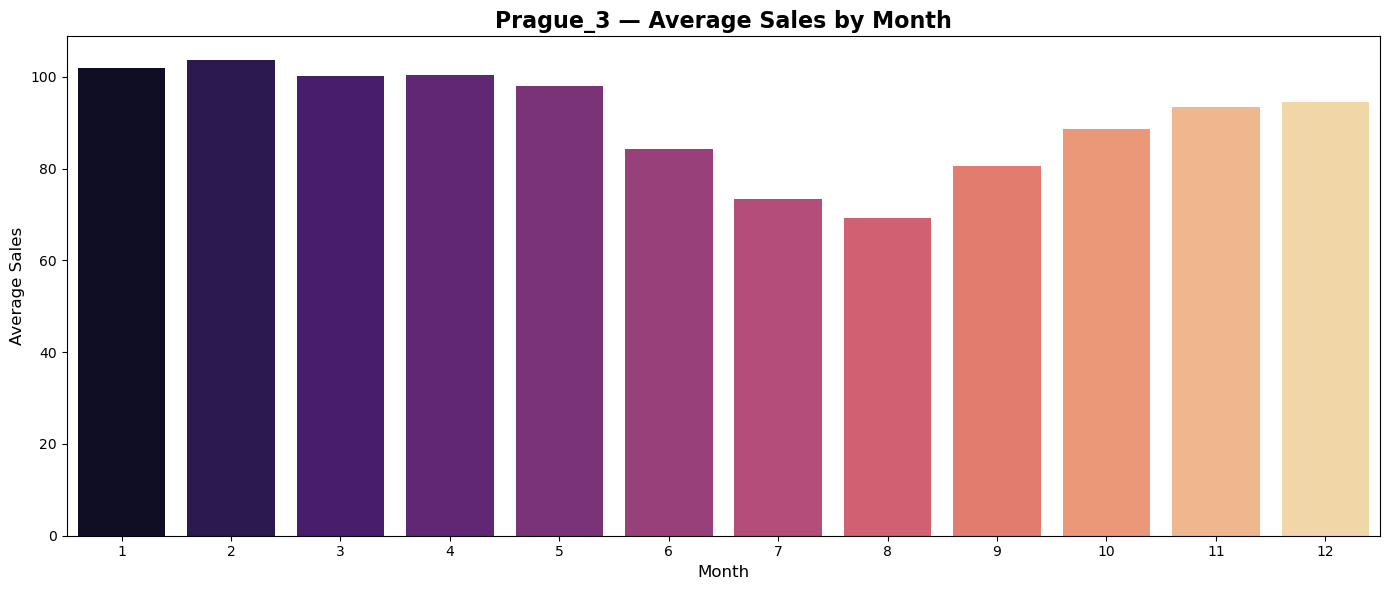

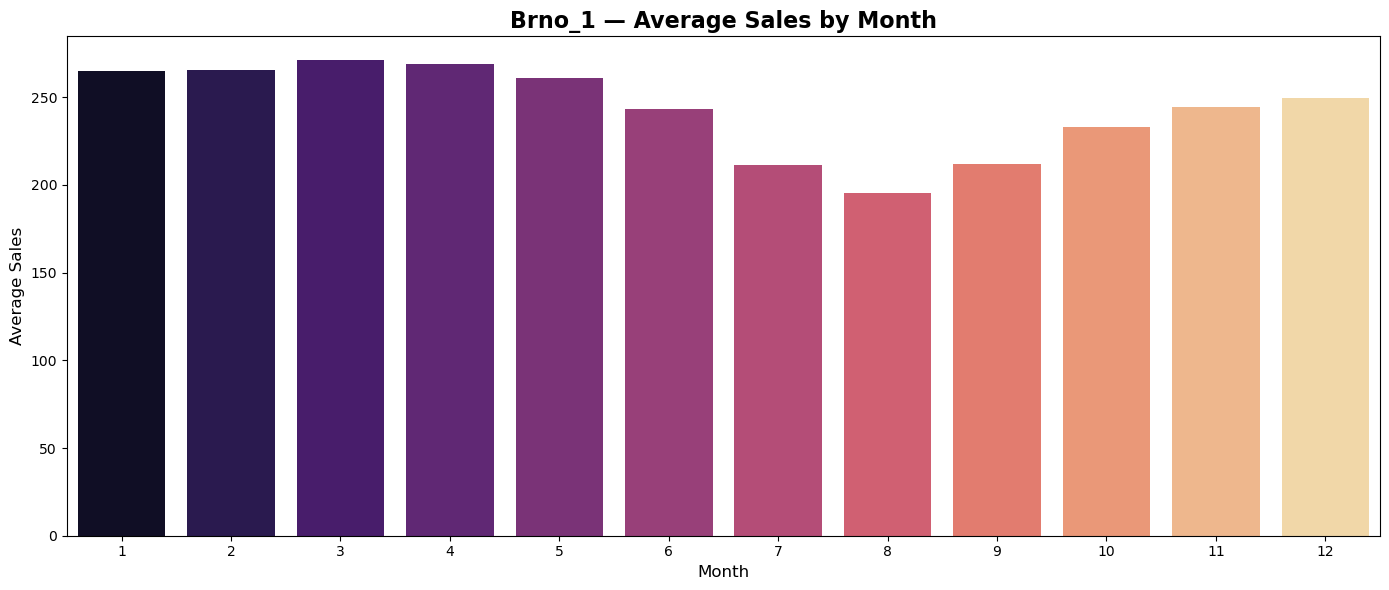

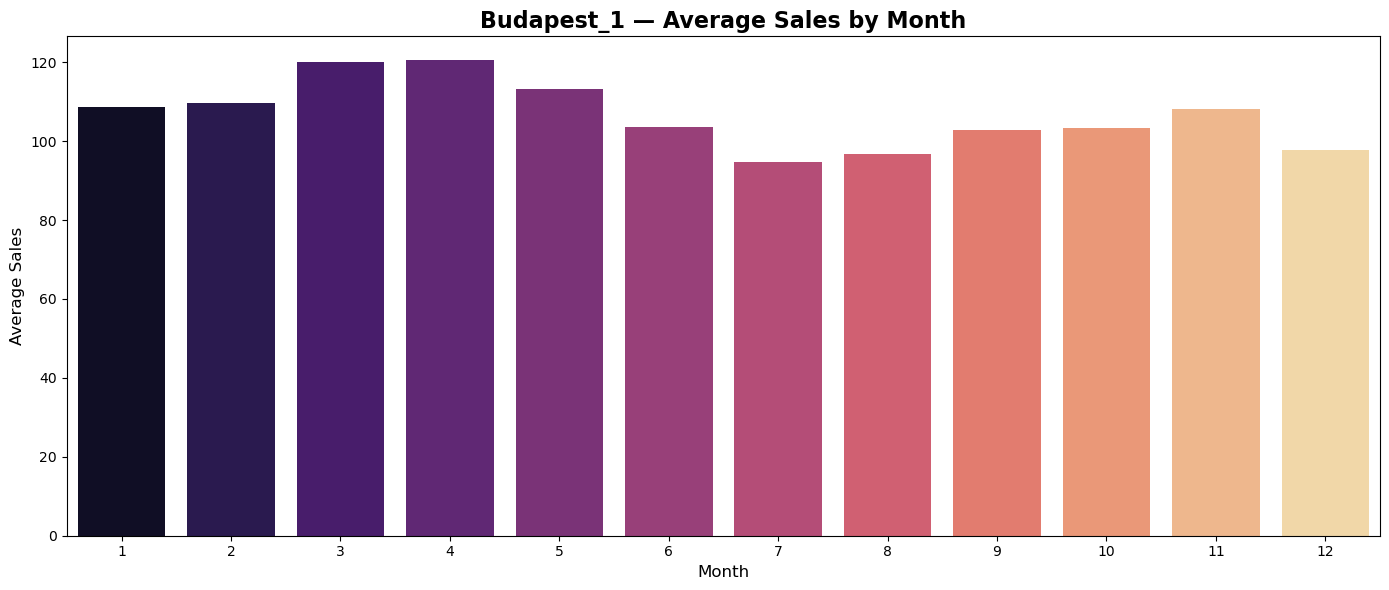

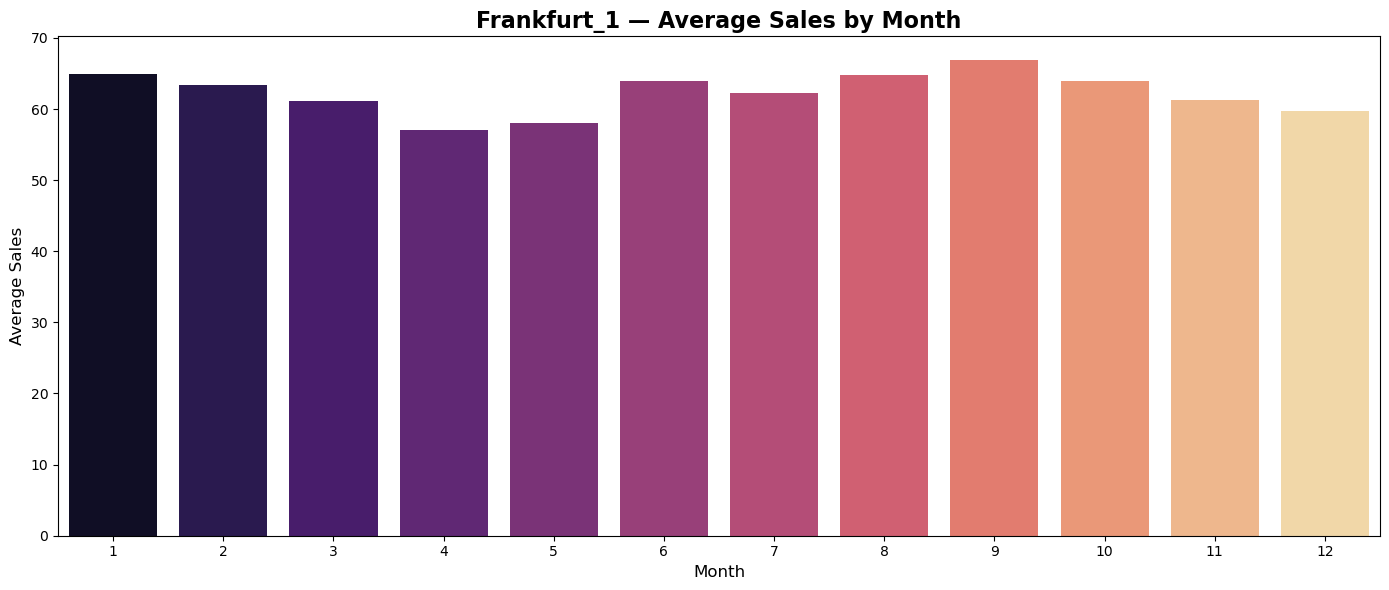

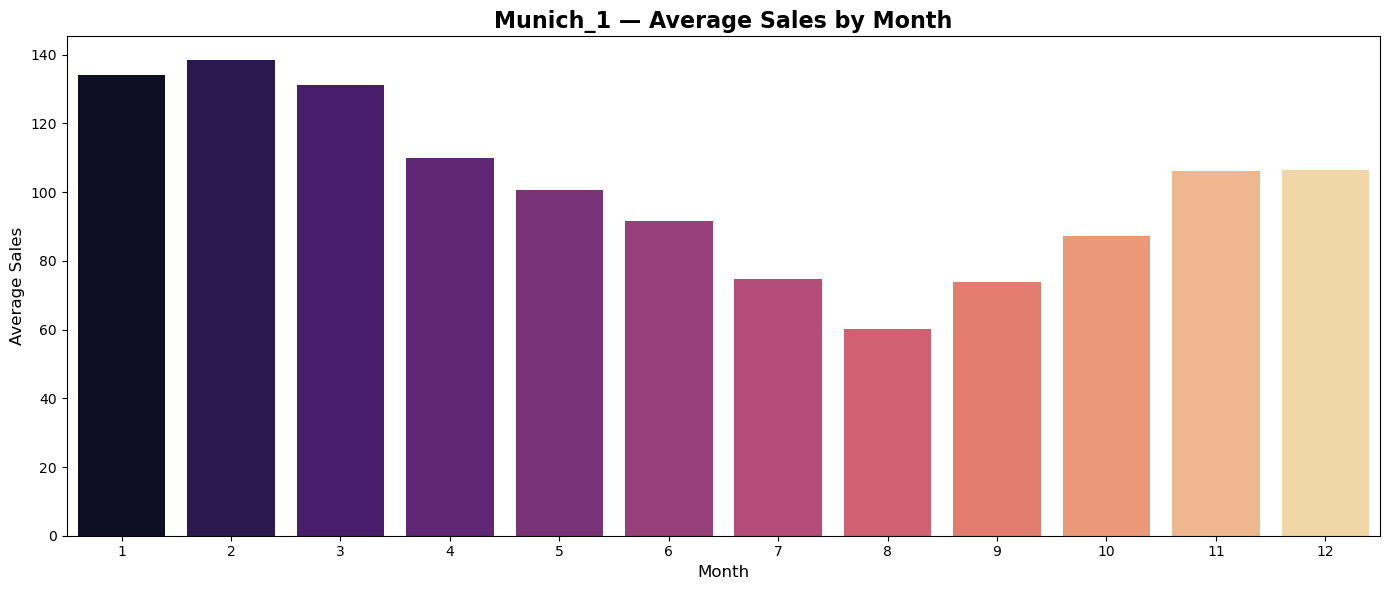

In [31]:
#| echo: false
monthly_average = (data
    .groupby(["warehouse", "month"], as_index=False)
    .agg(sales=("sales", "mean"))
)

for wh in warehouses:
    df_wh = monthly_average[monthly_average["warehouse"] == wh]
    if df_wh.empty:
        print(f"⚠️ No data for {wh}")
        continue

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(x="month", y="sales", data=df_wh, ax=ax, palette="magma", order=list(range(1, 13)))

    ax.set_title(f"{wh} — Average Sales by Month", fontsize=16, weight="bold")
    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("Average Sales", fontsize=12)
    plt.tight_layout()
    plt.show()


Plots of average monthly sales seems to reflect regionally differences in shopping habits of customers.

#### Average sales during holidays and common days

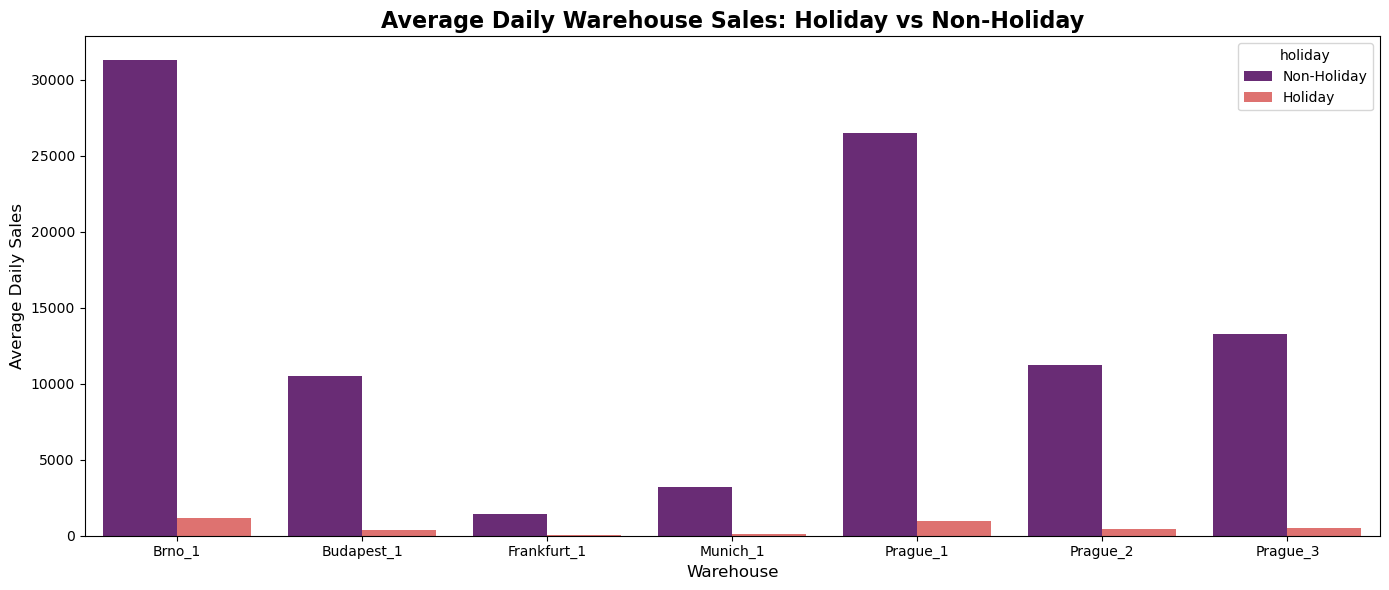

In [32]:
#| echo: false
# 1) daily totals per warehouse
daily_wh = (data
    .groupby(["date", "warehouse", "holiday"])["sales"]
    .sum()
    .reset_index()
)

# 2) average daily totals by holiday vs non-holiday
avg_holiday_sales = (daily_wh
    .groupby(["warehouse", "holiday"])["sales"]
    .mean()
    .reset_index()
)

# nice legend labels
avg_holiday_sales["holiday"] = avg_holiday_sales["holiday"].map({0: "Non-Holiday", 1: "Holiday"})

# 3) plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    x="warehouse", y="sales",
    hue="holiday",
    data=avg_holiday_sales,
    palette="magma",
    ax=ax
)

ax.set_title("Average Daily Warehouse Sales: Holiday vs Non-Holiday", fontsize=16, weight="bold")
ax.set_xlabel("Warehouse", fontsize=12)
ax.set_ylabel("Average Daily Sales", fontsize=12)
plt.tight_layout()
plt.show()

## Prediction

#### Data preparation

In [42]:
# feature engineering
lags = [1, 2, 3, 7, 14, 21, 28, 35, 42, 56]

for lag in lags:
    data[f"lag_{lag}"] = (
        data.groupby("unique_id")["sales"]
        .shift(lag)
    )


lags = [1, 7, 14, 28]

for lag in lags:
    data[f"orders_lag_{lag}"] = (
        data.groupby("warehouse")["total_orders"]
        .shift(lag)
    )


# rolling 
windows = [7, 14, 28]

for w in windows:
    data[f"roll_mean_{w}"] = (
        data.groupby("unique_id")["sales"]
        .shift(1)
        .rolling(w)
        .mean()
        )
    


# simple momentum signals 
data["trend_ratio"] = data["roll_mean_7"] / (data["roll_mean_28"] + 1e-6)
data["momentum_7"] = data["lag_1"] - data["lag_7"]


# warehouse daily total trend
data["warehouse_roll7"] = (
    data.groupby(["warehouse", "date"])["sales"]
    .transform("sum")
    .groupby(data["warehouse"])
    .transform(lambda x: x.shift(1).rolling(7).mean())
)


data["product_roll7"] = (
    data.groupby(["product_unique_id", "date"])["sales"]
    .transform("sum")
    .groupby(data["product_unique_id"])
    .transform(lambda x: x.shift(1).rolling(7).mean())
    )



data["orders_roll7"] = (
    data.groupby("warehouse")["total_orders"]
    .shift(1)
    .rolling(7)
    .mean()
)


In [43]:
# dropping redundant columns
data = data.drop(columns=['holiday_name', 'name', 'day' ])


In [44]:
cat_cols = [
    "warehouse",
    "day_of_week",
    "L1_category_name_en",
    "L2_category_name_en",
    "L3_category_name_en",
    "L4_category_name_en",
    "product_unique_id"
]

for col in cat_cols:
    data[col] = data[col].astype("category")



In [45]:
train_final = data[data["is_test"] == 0]
test_final  = data[data["is_test"] == 1]

In [46]:
train_final=train_final.dropna()

In [47]:
y = train_final["sales"]
X = train_final.drop(columns=["sales"])

In [48]:
# time based split
cutoff = data["date"].max() - pd.Timedelta(days=14)

train_mask = data["date"] < cutoff
valid_mask = data["date"] >= cutoff

X_train = X[train_mask]
X_valid = X[valid_mask]

y_train = y[train_mask]
y_valid = y[valid_mask]

C:\Users\Lucia\AppData\Local\Temp\ipykernel_13260\1303929620.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X[train_mask]
C:\Users\Lucia\AppData\Local\Temp\ipykernel_13260\1303929620.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_valid = X[valid_mask]


In [49]:
train_weights = X_train['weight'].values

valid_weights = X_valid['weight'].values

In [50]:
X_train_model = X_train.drop(columns=["unique_id", "date"])
X_valid_model = X_valid.drop(columns=["unique_id", "date"])

### Model

In [51]:
model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train_model,
    y_train,
    sample_weight=train_weights,
    eval_set=[(X_valid_model, y_valid)],
    eval_sample_weight=[valid_weights],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(200)]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8365
[LightGBM] [Info] Number of data points in the train set: 992567, number of used features: 47
[LightGBM] [Info] Start training from score 80.852346
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2340]	valid_0's l1: 12.7233	valid_0's l2: 959.369


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=5000,
              num_leaves=63, random_state=42, subsample=0.8)

In [52]:
pred = model.predict(X_valid_model)

wmae = np.sum(valid_weights * np.abs(y_valid - pred)) / np.sum(valid_weights)
mae = mean_absolute_error(y_valid, pred)
print("Validation WMAE:", wmae)
print("MAE:", mae)

Validation WMAE: 12.723309697441186
MAE: 17.97533235707734


## Conclusion

In this notebook, I cleaned and enriched the sales dataset with
calendar-based features and explored sales patterns across warehouses. Then, I created model for the predicting of sales and saved the results into solution.csv.

***
### End